# 06 Model Evaluation: Lift, Deciles, Gini, KS, and Calibration

## Loan Default Prediction and Credit Risk Scorecard

This notebook evaluates the champion model using credit risk and classification metrics. The goal is to determine whether the model provides useful borrower risk ranking, default concentration, and probability calibration for underwriting and portfolio monitoring.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [3]:
scores = pd.read_csv("../data/outputs/tree_model_score_output.csv")

scores.shape

(342392, 39)

In [4]:
scores.head()

,loan_amnt,term_months,int_rate,installment,grade,sub_grade,grade_risk_numeric,emp_length_years,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,application_type,mort_acc,pub_rec_bankruptcies,issue_year,issue_month,credit_history_months,loan_income_ratio,installment_income_ratio,high_dti_flag,high_revol_util_flag,recent_inquiry_flag,long_term_flag,income_band,dti_band,credit_history_band,actual_default,predicted_pd_tree_model,predicted_default_050,model_name
0,10000.0,36,10.49,324.98,B,B3,2,10.0,MORTGAGE,62000.0,Not Verified,debt_consolidation,9.50,0.0,0.0,16.0,1.0,8056.0,26.2,53.0,Individual,1.0,1.0,2016,10,289.0,0.161290,0.062899,0,0,0,0,Middle Income,Low DTI,Long Credit History,0,0.334686,0,LightGBM
1,4000.0,36,12.69,134.18,C,C2,3,10.0,MORTGAGE,102000.0,Not Verified,home_improvement,18.24,0.0,0.0,8.0,0.0,7132.0,52.4,10.0,Individual,2.0,0.0,2015,3,83.0,0.039216,0.015786,0,0,0,0,Upper Middle Income,Moderate DTI,Moderate Credit History,0,0.301948,0,LightGBM
2,22400.0,60,18.99,580.95,D,D3,4,10.0,MORTGAGE,70000.0,Not Verified,credit_card,25.72,0.0,1.0,7.0,1.0,11386.0,40.4,22.0,Individual,3.0,1.0,2016,12,279.0,0.320000,0.099591,0,0,0,1,Middle Income,High DTI,Long Credit History,0,0.639001,1,LightGBM
3,10000.0,36,10.99,327.34,B,B2,2,0.0,RENT,70000.0,Not Verified,debt_consolidation,17.59,0.0,1.0,13.0,0.0,10130.0,39.2,17.0,Individual,0.0,0.0,2014,1,100.0,0.142857,0.056115,0,0,0,0,Middle Income,Moderate DTI,Established Credit History,0,0.278931,0,LightGBM
4,5000.0,36,9.17,159.40,B,B2,2,0.0,OWN,62000.0,Source Verified,debt_consolidation,15.18,0.0,0.0,6.0,0.0,5129.0,68.4,12.0,Individual,1.0,0.0,2016,1,101.0,0.080645,0.030852,0,0,0,0,Middle Income,Moderate DTI,Established Credit History,0,0.261981,0,LightGBM


In [5]:
scores["model_name"].value_counts()

model_name
LightGBM    342392
Name: count, dtype: int64

In [6]:
y_true = scores["actual_default"]
y_prob = scores["predicted_pd_tree_model"]

print("Actual default rate:", round(y_true.mean() * 100, 2))
print("Average predicted PD:", round(y_prob.mean() * 100, 2))

Actual default rate: 21.24
Average predicted PD: 45.29


In [7]:
roc_auc = roc_auc_score(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)
gini = 2 * roc_auc - 1
brier = brier_score_loss(y_true, y_prob)

print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))
print("Gini:", round(gini, 4))
print("Brier Score:", round(brier, 4))

ROC-AUC: 0.7287
PR-AUC: 0.4196
Gini: 0.4574
Brier Score: 0.2107


## Core Model Evaluation

ROC-AUC measures the model's ability to rank defaulted borrowers above non-defaulted borrowers. Gini is a credit-risk-friendly transformation of ROC-AUC.

PR-AUC is useful because the default class is smaller than the non-default class.

Brier Score measures probability accuracy. Lower Brier Score indicates better probability calibration.

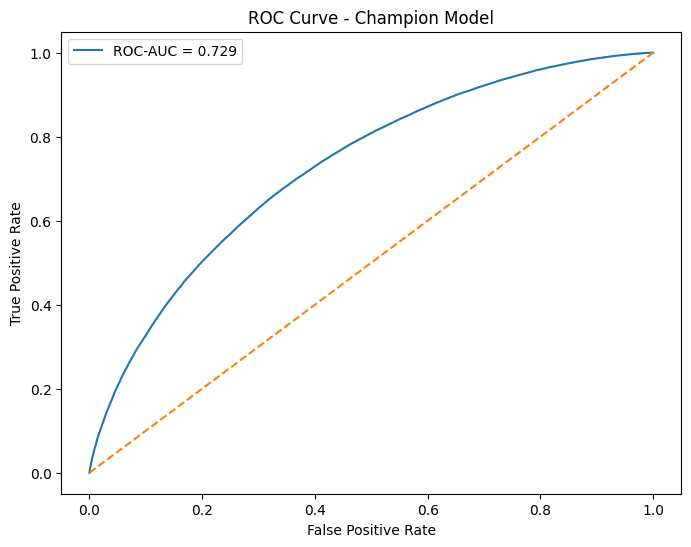

In [8]:
fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Champion Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

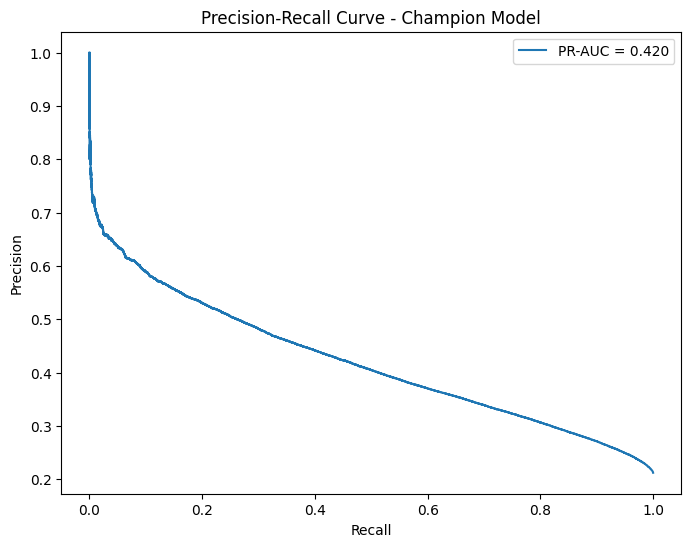

In [9]:
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.title("Precision-Recall Curve - Champion Model")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [10]:
evaluation_df = scores[["actual_default", "predicted_pd_tree_model"]].copy()

evaluation_df["risk_decile"] = pd.qcut(
    evaluation_df["predicted_pd_tree_model"],
    q=10,
    labels=False,
    duplicates="drop"
)

# Convert so decile 1 = highest risk
evaluation_df["risk_decile"] = 10 - evaluation_df["risk_decile"]

In [11]:
total_defaults = evaluation_df["actual_default"].sum()
overall_default_rate = evaluation_df["actual_default"].mean()

decile_table = (
    evaluation_df.groupby("risk_decile")
    .agg(
        loan_count=("actual_default", "count"),
        default_count=("actual_default", "sum"),
        avg_predicted_pd=("predicted_pd_tree_model", "mean"),
        observed_default_rate=("actual_default", "mean")
    )
    .reset_index()
    .sort_values("risk_decile")
)

decile_table["default_capture_rate"] = decile_table["default_count"] / total_defaults
decile_table["cumulative_defaults"] = decile_table["default_count"].cumsum()
decile_table["cumulative_default_capture_rate"] = decile_table["cumulative_defaults"] / total_defaults
decile_table["lift"] = decile_table["observed_default_rate"] / overall_default_rate

decile_table["avg_predicted_pd_pct"] = (decile_table["avg_predicted_pd"] * 100).round(2)
decile_table["observed_default_rate_pct"] = (decile_table["observed_default_rate"] * 100).round(2)
decile_table["default_capture_rate_pct"] = (decile_table["default_capture_rate"] * 100).round(2)
decile_table["cumulative_default_capture_rate_pct"] = (decile_table["cumulative_default_capture_rate"] * 100).round(2)
decile_table["lift"] = decile_table["lift"].round(2)

decile_table

,risk_decile,loan_count,default_count,avg_predicted_pd,observed_default_rate,default_capture_rate,cumulative_defaults,cumulative_default_capture_rate,lift,avg_predicted_pd_pct,observed_default_rate_pct,default_capture_rate_pct,cumulative_default_capture_rate_pct
0,1,34240,17487,0.781616,0.510718,0.240513,17487,0.240513,2.41,78.16,51.07,24.05,24.05
1,2,34239,12452,0.678062,0.363679,0.171263,29939,0.411776,1.71,67.81,36.37,17.13,41.18
2,3,34239,9912,0.603479,0.289494,0.136328,39851,0.548104,1.36,60.35,28.95,13.63,54.81
3,4,34239,8303,0.539730,0.242501,0.114198,48154,0.662302,1.14,53.97,24.25,11.42,66.23
4,5,34239,6850,0.480788,0.200064,0.094214,55004,0.756516,0.94,48.08,20.01,9.42,75.65
5,6,34239,5574,0.422842,0.162797,0.076664,60578,0.833180,0.77,42.28,16.28,7.67,83.32
6,7,34239,4657,0.362780,0.136014,0.064052,65235,0.897231,0.64,36.28,13.60,6.41,89.72
7,8,34239,3569,0.299363,0.104238,0.049087,68804,0.946319,0.49,29.94,10.42,4.91,94.63
8,9,34239,2571,0.227793,0.075090,0.035361,71375,0.981680,0.35,22.78,7.51,3.54,98.17
9,10,34240,1332,0.132878,0.038902,0.018320,72707,1.000000,0.18,13.29,3.89,1.83,100.00


In [12]:
decile_table.to_csv("../data/outputs/champion_model_decile_analysis.csv", index=False)

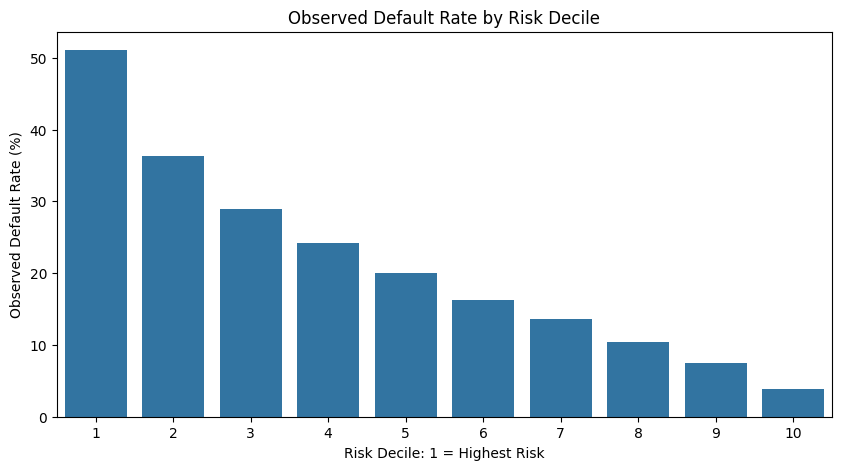

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(data=decile_table, x="risk_decile", y="observed_default_rate_pct")
plt.title("Observed Default Rate by Risk Decile")
plt.xlabel("Risk Decile: 1 = Highest Risk")
plt.ylabel("Observed Default Rate (%)")
plt.show()

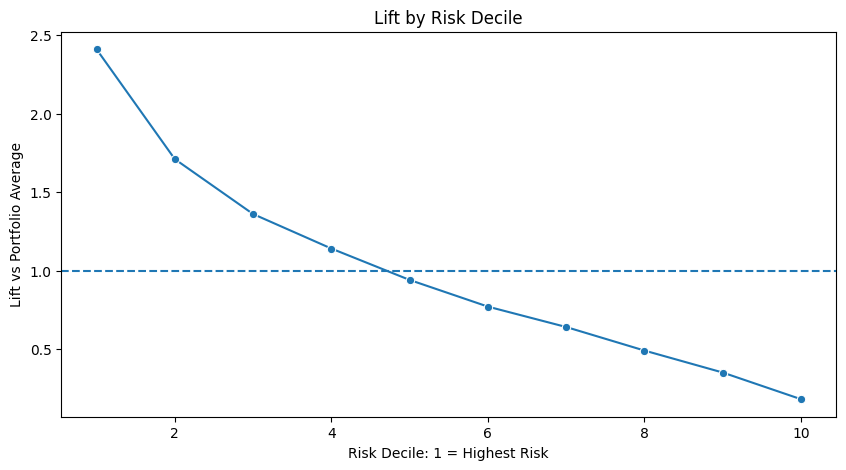

In [14]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=decile_table, x="risk_decile", y="lift", marker="o")
plt.axhline(1, linestyle="--")
plt.title("Lift by Risk Decile")
plt.xlabel("Risk Decile: 1 = Highest Risk")
plt.ylabel("Lift vs Portfolio Average")
plt.show()

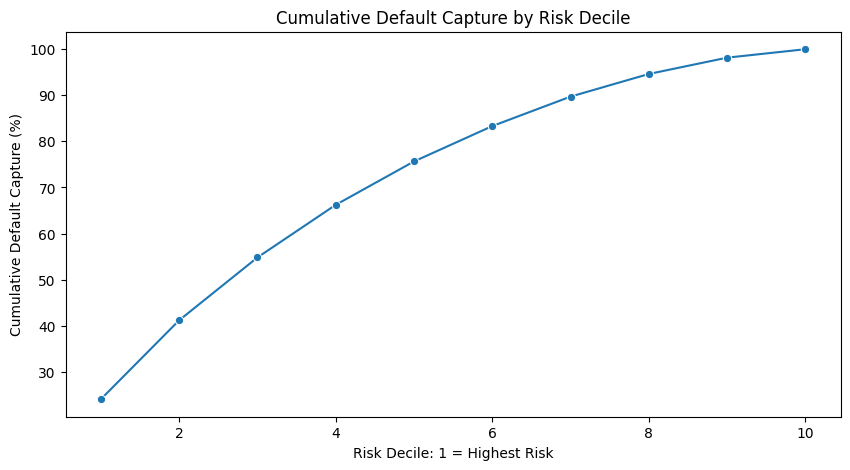

In [15]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=decile_table,
    x="risk_decile",
    y="cumulative_default_capture_rate_pct",
    marker="o"
)
plt.title("Cumulative Default Capture by Risk Decile")
plt.xlabel("Risk Decile: 1 = Highest Risk")
plt.ylabel("Cumulative Default Capture (%)")
plt.show()

In [16]:
ks_df = evaluation_df.copy()
ks_df["non_default"] = 1 - ks_df["actual_default"]

ks_table = (
    ks_df.groupby("risk_decile")
    .agg(
        defaults=("actual_default", "sum"),
        non_defaults=("non_default", "sum")
    )
    .reset_index()
    .sort_values("risk_decile")
)

ks_table["cum_defaults_pct"] = ks_table["defaults"].cumsum() / ks_table["defaults"].sum()
ks_table["cum_non_defaults_pct"] = ks_table["non_defaults"].cumsum() / ks_table["non_defaults"].sum()
ks_table["ks"] = abs(ks_table["cum_defaults_pct"] - ks_table["cum_non_defaults_pct"])

ks_statistic = ks_table["ks"].max()

print("KS Statistic:", round(ks_statistic, 4))

ks_table

KS Statistic: 0.333


,risk_decile,defaults,non_defaults,cum_defaults_pct,cum_non_defaults_pct,ks
0,1,17487,16753,0.240513,0.062121,0.178393
1,2,12452,21787,0.411776,0.142907,0.268869
2,3,9912,24327,0.548104,0.233113,0.314991
3,4,8303,25936,0.662302,0.329284,0.333018
4,5,6850,27389,0.756516,0.430843,0.325672
5,6,5574,28665,0.833180,0.537134,0.296046
6,7,4657,29582,0.897231,0.646825,0.250406
7,8,3569,30670,0.946319,0.760550,0.185769
8,9,2571,31668,0.981680,0.877976,0.103704
9,10,1332,32908,1.000000,1.000000,0.000000


In [17]:
ks_table.to_csv("../data/outputs/champion_model_ks_table.csv", index=False)

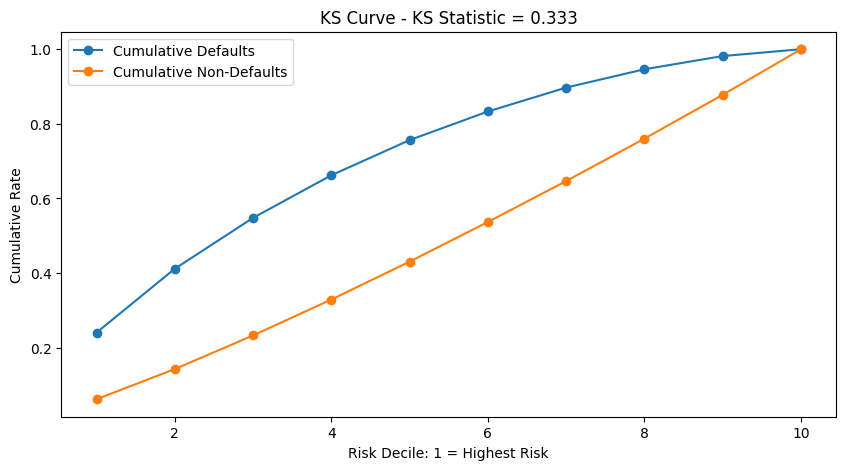

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(ks_table["risk_decile"], ks_table["cum_defaults_pct"], marker="o", label="Cumulative Defaults")
plt.plot(ks_table["risk_decile"], ks_table["cum_non_defaults_pct"], marker="o", label="Cumulative Non-Defaults")
plt.title(f"KS Curve - KS Statistic = {ks_statistic:.3f}")
plt.xlabel("Risk Decile: 1 = Highest Risk")
plt.ylabel("Cumulative Rate")
plt.legend()
plt.show()

In [19]:
prob_true, prob_pred = calibration_curve(
    y_true,
    y_prob,
    n_bins=10,
    strategy="quantile"
)

calibration_df = pd.DataFrame({
    "mean_predicted_pd": prob_pred,
    "observed_default_rate": prob_true
})

calibration_df["mean_predicted_pd_pct"] = (calibration_df["mean_predicted_pd"] * 100).round(2)
calibration_df["observed_default_rate_pct"] = (calibration_df["observed_default_rate"] * 100).round(2)

calibration_df

,mean_predicted_pd,observed_default_rate,mean_predicted_pd_pct,observed_default_rate_pct
0,0.132878,0.038902,13.29,3.89
1,0.227793,0.075090,22.78,7.51
2,0.299363,0.104238,29.94,10.42
3,0.362780,0.136014,36.28,13.60
4,0.422842,0.162797,42.28,16.28
5,0.480788,0.200064,48.08,20.01
6,0.539730,0.242501,53.97,24.25
7,0.603479,0.289494,60.35,28.95
8,0.678062,0.363679,67.81,36.37
9,0.781616,0.510718,78.16,51.07


In [20]:
calibration_df.to_csv("../data/outputs/champion_model_calibration.csv", index=False)

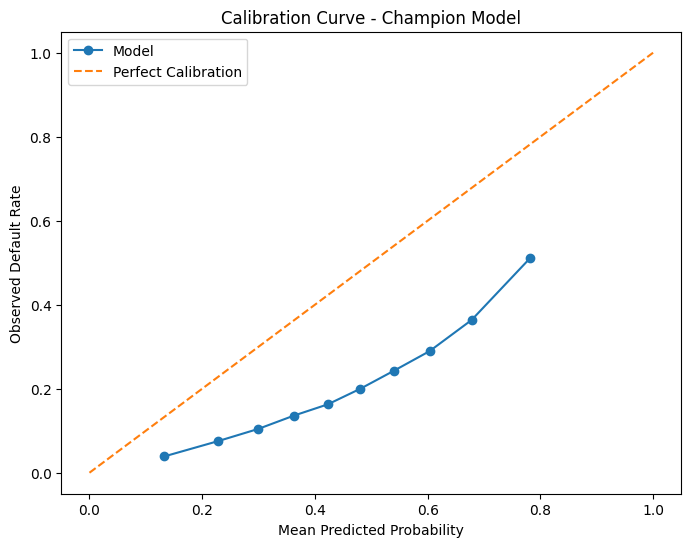

In [21]:
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.title("Calibration Curve - Champion Model")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.legend()
plt.show()

## Calibration Interpretation

Calibration checks whether predicted probabilities are reliable. For example, if borrowers scored around 20% PD actually default around 20% of the time, the model is well calibrated.

If the calibration curve deviates from the diagonal line, the model may still rank borrowers well but may require probability calibration before being used as a probability of default model.

In [22]:
evaluation_summary = pd.DataFrame({
    "metric": [
        "ROC-AUC",
        "PR-AUC",
        "Gini",
        "KS Statistic",
        "Brier Score",
        "Average Predicted PD",
        "Observed Default Rate"
    ],
    "value": [
        roc_auc,
        pr_auc,
        gini,
        ks_statistic,
        brier,
        y_prob.mean(),
        y_true.mean()
    ]
})

evaluation_summary["value"] = evaluation_summary["value"].round(4)

evaluation_summary

,metric,value
0,ROC-AUC,0.7287
1,PR-AUC,0.4196
2,Gini,0.4574
3,KS Statistic,0.3330
4,Brier Score,0.2107
5,Average Predicted PD,0.4529
6,Observed Default Rate,0.2124


In [23]:
evaluation_summary.to_csv("../data/outputs/champion_model_evaluation_summary.csv", index=False)

# Model Evaluation Business Interpretation

The champion model provides stronger borrower risk ranking than the naive baseline and logistic regression benchmark. ROC-AUC and Gini indicate that the model can separate higher-risk and lower-risk borrowers better than random selection.

The decile analysis is especially important for credit risk use. If the highest-risk deciles show materially higher observed default rates than the portfolio average, the model can support manual review prioritization and portfolio monitoring.

The lift chart shows whether the model concentrates defaults in the highest-risk groups. A lift greater than 1 in the top deciles means the model is better than random selection at identifying risky borrowers.

Calibration should be reviewed before using the output as a true probability of default. If predicted PD and observed default rates are not closely aligned, probability calibration may be required before production use.

# Deep Evaluation Summary

## Key Actions Completed

- Calculated ROC-AUC, PR-AUC, Gini, KS statistic, and Brier Score.
- Created ROC and precision-recall curves.
- Built decile analysis to evaluate default concentration.
- Created lift chart and cumulative default capture chart.
- Built KS table and KS curve.
- Reviewed calibration using quantile-based calibration curve.
- Saved all model evaluation outputs for dashboard and reporting.

## Next Step

The next notebook will tune business thresholds and convert predicted probabilities into risk bands for underwriting and portfolio monitoring use.